Nifty 50 Stock Price Forecasting using Temporal Fusion Transformer (TFT) | Python, PyTorch, yFinance, sklearn

Developed a multivariate time series forecasting model to predict Nifty 50 stock prices using Temporal Fusion Transformer. Engineered features such as log-transformed volume, daily returns, and categorical time indicators. Scaled inputs and prepared training/testing sets using PyTorch Forecasting's TimeSeriesDataSet. Trained and evaluated the model with SMAPE loss and reported R² and MSE metrics. Implemented data preprocessing, model tuning, and post-processing to unscale predictions and interpret results. Demonstrated proficiency in deep learning for time series, model interpretability, and working with financial data APIs.




In [481]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [482]:
df = yf.download('^NSEI', start='2020-01-01', end='2025-01-01')
df

/tmp/ipython-input-482-2979282317.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^NSEI', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800
...,...,...,...,...,...
2024-12-24,23727.650391,23867.650391,23685.150391,23769.099609,177700
2024-12-26,23750.199219,23854.500000,23653.599609,23775.800781,177700


In [483]:
df = df.reset_index()
df.rename(columns={'Price Ticker': 'Price'}, inplace=True)

In [484]:
df['time_idx'] = range(len(df))
df['group'] = 0
df.head()

Price,Date,Close,High,Low,Open,Volume,time_idx,group
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,
0,2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100,0,0
1,2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700,1,0
2,2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800,2,0
3,2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500,3,0
4,2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800,4,0


In [485]:
df['return'] = df['Close'].pct_change().fillna(0)
df['volume_log'] = np.log1p(df['Volume'])
df['day_of_week'] = df['Date'].dt.dayofweek
df

Price,Date,Close,High,Low,Open,Volume,time_idx,group,return,volume_log,day_of_week
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,,,
0,2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100,0,0,0.000000,12.625115,2
1,2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700,1,0,0.008184,12.918289,3
2,2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800,2,0,-0.004523,12.968748,4
3,2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500,3,0,-0.019106,12.890434,0
4,2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800,4,0,0.004995,13.012104,1
...,...,...,...,...,...,...,...,...,...,...,...
1232,2024-12-24,23727.650391,23867.650391,23685.150391,23769.099609,177700,1232,0,-0.001086,12.087858,1
1233,2024-12-26,23750.199219,23854.500000,23653.599609,23775.800781,177700,1233,0,0.000950,12.087858,3
1234,2024-12-27,23813.400391,23938.849609,23800.599609,23801.400391,176800,1234,0,0.002661,12.082780,4


In [486]:
print(df.columns)

MultiIndex([(       'Date',      ''),
            (      'Close', '^NSEI'),
            (       'High', '^NSEI'),
            (        'Low', '^NSEI'),
            (       'Open', '^NSEI'),
            (     'Volume', '^NSEI'),
            (   'time_idx',      ''),
            (      'group',      ''),
            (     'return',      ''),
            ( 'volume_log',      ''),
            ('day_of_week',      '')],
           names=['Price', 'Ticker'])


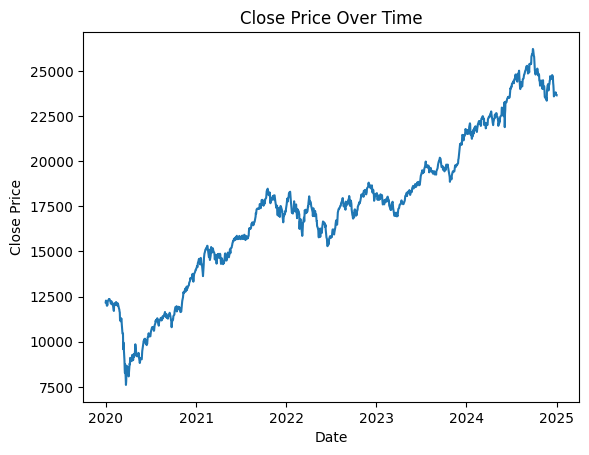

In [487]:
x=df['Date']
y=df['Close']
plt.plot(x,y)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Close Price Over Time')
plt.show()

In [488]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Close', 'Open', 'High', 'Low', 'return', 'volume_log']] = scaler.fit_transform(df[['Close', 'Open', 'High', 'Low', 'return', 'volume_log']])
df

Price,Date,Close,High,Low,Open,Volume,time_idx,group,return,volume_log,day_of_week
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,,,
0,2020-01-01,-1.231564,-1.243861,-1.212269,-1.229611,304100,0,0,-0.050658,0.016374,2
1,2020-01-02,-1.207758,-1.227705,-1.205113,-1.230471,407700,1,0,0.629538,0.214082,3
2,2020-01-03,-1.221022,-1.233504,-1.206045,-1.215533,428800,2,0,-0.426565,0.248110,4
3,2020-01-06,-1.276801,-1.254146,-1.257924,-1.237145,396500,3,0,-1.638623,0.195297,0
4,2020-01-07,-1.262498,-1.260577,-1.250482,-1.258996,447800,4,0,0.364463,0.277348,1
...,...,...,...,...,...,...,...,...,...,...,...
1232,2024-12-24,1.525185,1.535151,1.539915,1.532627,177700,1232,0,-0.140929,-0.345937,1
1233,2024-12-26,1.530570,1.532013,1.532377,1.534227,177700,1233,0,0.028327,-0.345937,3
1234,2024-12-27,1.545661,1.552142,1.567497,1.540340,176800,1234,0,0.170515,-0.349361,4


In [489]:
max_encoder_length = 30
max_prediction_length = 5

In [490]:
train_data = df[df['Date'] < '2024-01-01']
val_data = df[df['Date'] >= '2024-01-01']


In [491]:
!pip install pytorch-forecasting

In [492]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_lightning import Trainer
from pytorch_forecasting.data.encoders import GroupNormalizer

In [493]:
train_data['day_of_week'] = train_data['day_of_week'].astype(str)
train_data['group'] = train_data['group'].astype(str)

/tmp/ipython-input-493-3398830352.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['day_of_week'] = train_data['day_of_week'].astype(str)
/tmp/ipython-input-493-3398830352.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['group'] = train_data['group'].astype(str)


In [494]:
from pytorch_forecasting.data.encoders import GroupNormalizer, NaNLabelEncoder

train_data.columns = train_data.columns.droplevel('Ticker')
val_data.columns = val_data.columns.droplevel('Ticker')

train_data['day_of_week'] = train_data['day_of_week'].astype(str)
val_data['day_of_week'] = val_data['day_of_week'].astype(str)

ts_dataset = TimeSeriesDataSet(
    train_data,
    time_idx='time_idx',
    target='Close',
    group_ids=['group'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=['time_idx'],
    time_varying_unknown_reals=['Open', 'High', 'Low', 'Close', 'return', 'volume_log'],
    time_varying_known_categoricals=['day_of_week'],
    categorical_encoders={"day_of_week": NaNLabelEncoder(add_nan=True), "group": NaNLabelEncoder(add_nan=True)},
    target_normalizer=GroupNormalizer(groups=['group']),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

/tmp/ipython-input-494-1527298591.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['day_of_week'] = train_data['day_of_week'].astype(str)
/tmp/ipython-input-494-1527298591.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data['day_of_week'] = val_data['day_of_week'].astype(str)


In [495]:
val_dataset = TimeSeriesDataSet(
    val_data,
    time_idx="time_idx",
    target="Close",
    group_ids=["group"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=["Open", "High", "Low", "Close", "return", "volume_log"],
    time_varying_known_categoricals=["day_of_week"],
    target_normalizer=GroupNormalizer(groups=['group']),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)



In [496]:
train_loader = ts_dataset.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader = val_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

In [497]:
pip install -U pytorch-lightning lightning pytorch-forecasting

In [498]:
from pytorch_lightning import seed_everything
import torch
from pytorch_forecasting.metrics import QuantileLoss
seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [499]:
from pytorch_forecasting import TemporalFusionTransformer
from lightning.pytorch import Trainer

model = TemporalFusionTransformer.from_dataset(
    ts_dataset,
    learning_rate=0.005,
    hidden_size=64,
    attention_head_size=1,
    dropout=0.2,
    loss=QuantileLoss(),
    log_interval=10,
    log_val_interval=1,
)

trainer = Trainer(max_epochs=25,accelerator="gpu" if torch.cuda.is_available() else "cpu")



/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.11/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU avai

In [500]:
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 24     | train
3  | prescalers                         | ModuleDict                      | 176    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 5.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 14.8 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 3.8 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 16.8 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 1

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (14) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


In [501]:
actuals = torch.cat([y[0] for x, y in iter(val_loader)])
val_preds = model.predict(val_loader)

In [502]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(actuals.cpu().numpy(), val_preds.cpu().numpy())
r2 = r2_score(actuals.cpu().numpy(), val_preds.cpu().numpy())
print(f'Validation MSE: {mse:.4f}')
print(f'R2 Score: {r2:.4f}')


Validation MSE: 0.0079
R2 Score: 0.8971


In [506]:
test_df = yf.download('^NSEI', start='2025-01-01', end='2025-03-01').reset_index()
test_df['time_idx'] = range(df['time_idx'].max() + 1, df['time_idx'].max() + 1 + len(test_df))
test_df['group'] = 0
test_df['return'] = test_df['Close'].pct_change().fillna(0)
test_df['volume_log'] = np.log1p(test_df['Volume'])
test_df['day_of_week'] = test_df['Date'].dt.dayofweek
test_df.columns = test_df.columns.droplevel('Ticker')

scaled_cols = ['Close', 'Open', 'High', 'Low', 'return', 'volume_log']
test_df[scaled_cols] = scaler.transform(test_df[scaled_cols])
test_df.head()

/tmp/ipython-input-506-3487853677.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_df = yf.download('^NSEI', start='2025-01-01', end='2025-03-01').reset_index()
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Price,Date,Close,High,Low,Open,Volume,time_idx,group,return,volume_log,day_of_week
0,2025-01-01,1.528827,1.524448,1.510685,1.501236,154900,1237,0,-0.050658,-0.438539,2
1,2025-01-02,1.635263,1.620833,1.555779,1.535946,283200,1238,0,1.509728,-0.031643,3
2,2025-01-03,1.591351,1.613614,1.609401,1.634668,312300,1239,0,-0.682554,0.034317,4
3,2025-01-06,1.498538,1.588199,1.508081,1.598704,278100,1240,0,-1.396490,-0.043898,0
4,2025-01-07,1.520470,1.517862,1.528603,1.511325,262300,1241,0,0.272597,-0.083343,1


In [507]:
test_df['day_of_week'] = test_df['day_of_week'].astype(str)
test_ts_dataset = TimeSeriesDataSet.from_dataset(ts_dataset,test_df,predict=True,stop_randomization=True)

test_loader = test_ts_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

/usr/local/lib/python3.11/dist-packages/pytorch_forecasting/data/encoders.py:401: UserWarning: Found 1 unknown classes which were set to NaN
  warnings.warn(


In [508]:
test_preds = model.predict(test_loader, return_x=True)

In [509]:
close_scaler = StandardScaler()
close_scaler.mean_ = scaler.mean_[0:1]
close_scaler.scale_ = scaler.scale_[0:1]
test_preds_unscaled = test_preds[0] * scaler.scale_[0] + scaler.mean_[0]

In [510]:
result_df = pd.DataFrame({"Date": test_df["Date"].iloc[-len(test_preds_unscaled[0]):].values,"Predicted_Close": test_preds_unscaled[0].cpu().numpy()})
result_df.head()

,Date,Predicted_Close
0,2025-02-21,21575.875000
1,2025-02-24,21569.718750
2,2025-02-25,21597.332031
3,2025-02-27,21598.826172
4,2025-02-28,21615.957031
